In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [31]:
df=pd.read_csv("/content/cgpaPRED.csv")

In [32]:
df

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03
...,...,...,...,...,...
374,0.10,0.10,0.20,0.14,0.14
375,0.10,0.10,0.20,0.14,0.14
376,0.10,0.10,0.20,0.14,0.14
377,0.10,0.10,0.20,0.14,0.14


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEM 1   379 non-null    float64
 1   SEM 2   379 non-null    float64
 2   SEM 3   379 non-null    float64
 3   SEM 4   379 non-null    float64
 4   SEM 5   379 non-null    float64
dtypes: float64(5)
memory usage: 14.9 KB


In [34]:
df.describe()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
count,379.000000,379.000000,379.000000,379.000000,379.000000
mean,5.908707,6.015858,6.103852,6.167546,6.050765
std,3.147572,3.139440,3.078922,3.131259,3.091451
min,0.100000,0.100000,0.130000,0.120000,0.140000
25%,4.080000,4.275000,4.870000,4.990000,4.290000
50%,7.150000,7.240000,7.500000,7.450000,7.420000
75%,8.190000,8.320000,8.225000,8.440000,8.220000
max,9.800000,9.880000,9.730000,9.880000,9.640000


In [35]:
df.isnull().sum()

,0
SEM 1,0
SEM 2,0
SEM 3,0
SEM 4,0
SEM 5,0


In [36]:
sum(df.duplicated())

48

In [37]:
df.drop_duplicates(inplace=True)

In [38]:
sum(df.duplicated())

0

In [39]:
df.corr()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
SEM 1,1.000000,0.953031,0.936928,0.917976,0.973233
SEM 2,0.953031,1.000000,0.959835,0.944268,0.985253
SEM 3,0.936928,0.959835,1.000000,0.953654,0.982953
SEM 4,0.917976,0.944268,0.953654,1.000000,0.974067
SEM 5,0.973233,0.985253,0.982953,0.974067,1.000000


In [40]:
x = df.loc[:, df.columns != "SEM 5"]
y = df['SEM 5']


In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
model=LinearRegression()

In [43]:
model.fit(x_train,y_train)

LinearRegression()

In [44]:
y_pred=model.predict(x_test)

In [45]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Evaluation Metrics")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Evaluation Metrics
MAE : 0.002598520559464134
MSE : 8.377509660473589e-06
RMSE: 0.0028943927965073414
R² Score: 0.9999985284819518


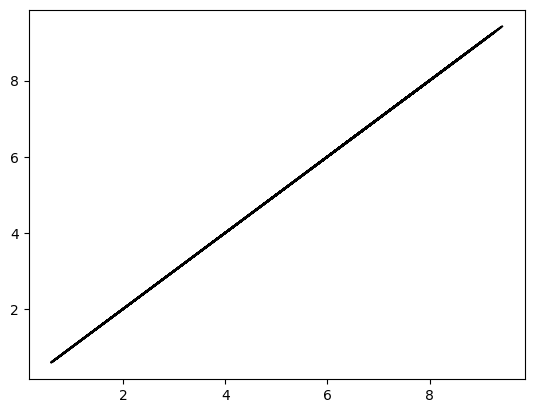

In [46]:

plt.plot(y_test, y_pred, color='black', label='Model Predictions')


<Axes: >

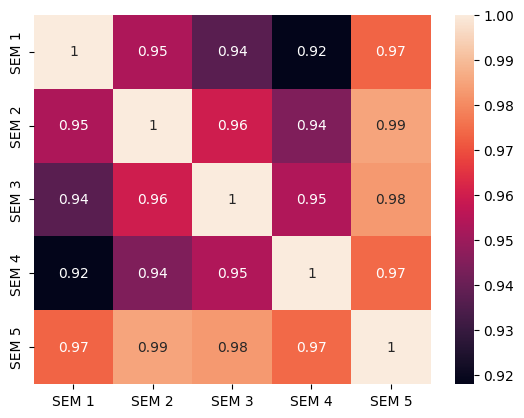

In [47]:
sns.heatmap(df.corr(),annot=True)

<Axes: ylabel='SEM 5'>

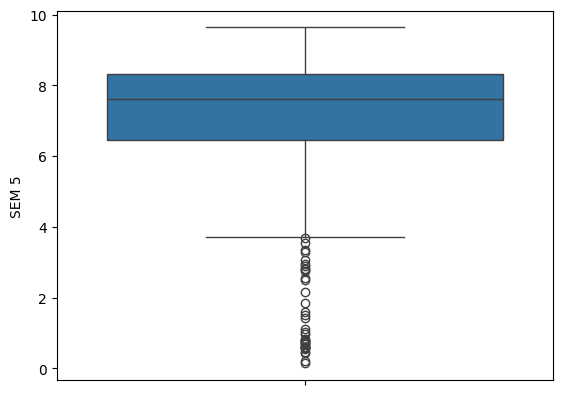

In [48]:
sns.boxplot(df['SEM 5'])

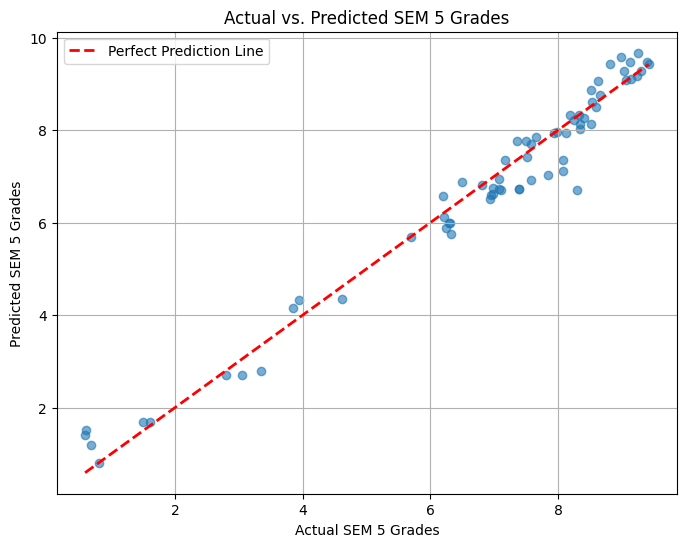

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual SEM 5 Grades")
plt.ylabel("Predicted SEM 5 Grades")
plt.title("Actual vs. Predicted SEM 5 Grades")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.grid(True)
plt.legend()
plt.show()

In [49]:
#LinearRegression
x = df[["SEM 1"]]
y = df['SEM 5']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [50]:
y_pred=model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Evaluation Metrics")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Evaluation Metrics
MAE : 0.3208784366607838
MSE : 0.1842053856516896
RMSE: 0.4291915489052523
R² Score: 0.9676441376320083


In [51]:
new_data = [[7.20]]
prediction = model.predict(new_data)

print("\nPrediction")
print(f"Predicted Final Marks: {prediction[0]:.2f}")


Prediction
Predicted Final Marks: 7.31


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
"""Description
This dataset contains semester-wise academic performance data of BTech students from GIET University. It includes the grades of students from their 1st to 4th semesters, along with their corresponding 5th-semester grades. The dataset is intended for use in educational data mining and machine learning applications, specifically for predicting the 5th-semester grades of students based on their past performance.The dataset consists of 379 student records, with each record containing the following attributes:

SEM 1: Grade obtained in the 1st semester.

SEM 2: Grade obtained in the 2nd semester.

SEM 3: Grade obtained in the 3rd semester.

SEM 4: Grade obtained in the 4th semester.

SEM 5: Grade obtained in the 5th semester (target variable for prediction).The grades are represented on a scale of 0 to 10, where 10 is the highest achievable grade. This dataset can be used to develop predictive models for academic performance, identify trends in student performance, and support decision-making in educational institutions.

Keywords:
Grade Prediction, Student Performance, Educational Data Mining, Academic Analytics, Machine Learning, GIET University

Potential Applications:

Predicting student performance in future semesters.

Identifying at-risk students for early intervention.

Analyzing trends in academic performance over time."""


'Description\nThis dataset contains semester-wise academic performance data of BTech students from GIET University. It includes the grades of students from their 1st to 4th semesters, along with their corresponding 5th-semester grades. The dataset is intended for use in educational data mining and machine learning applications, specifically for predicting the 5th-semester grades of students based on their past performance.The dataset consists of 379 student records, with each record containing the following attributes:\n\nSEM 1: Grade obtained in the 1st semester.\n\nSEM 2: Grade obtained in the 2nd semester.\n\nSEM 3: Grade obtained in the 3rd semester.\n\nSEM 4: Grade obtained in the 4th semester.\n\nSEM 5: Grade obtained in the 5th semester (target variable for prediction).The grades are represented on a scale of 0 to 10, where 10 is the highest achievable grade. This dataset can be used to develop predictive models for academic performance, identify trends in student performance, a